# Setup

In [149]:
import warnings
import functools

import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, cross_validate
import sklearn.metrics

from data import MET_Data
import utils

In [150]:
def get_irreducible_mask(swc_parents):
    degrees = np.zeros_like(swc_parents)
    has_parent = (swc_parents != -1)
    degrees[has_parent] += 1
    (parent_idx, num_children) = np.unique(swc_parents[has_parent], return_counts = True)
    degrees[parent_idx] += num_children
    irreducible_mask = (degrees != 2)
    return irreducible_mask

def build_histograms(swc_coords, swc_types, swc_parents, r_edges, z_edges, irreducible = False):
    structure_groupings = {"axon": [2], "basal": [3], "apical": [4]}
    disk_areas = np.pi*(r_edges[1:]**2 - r_edges[:-1]**2)
    disk_areas = disk_areas / disk_areas.max()
    histograms = {}
    for (coords, types, parents) in zip(swc_coords, swc_types, swc_parents):
        is_soma = (types == 1)
        centered_xy = coords[:, :2] - coords[is_soma, :2].mean(0)
        r = np.square(centered_xy).sum(1)**0.5
        centered_z = coords[:, 2] - 0.5
        irred_mask = get_irreducible_mask(parents) if irreducible else True
        for (structure, struct_ids) in structure_groupings.items():
            is_target = np.isin(types, struct_ids) & irred_mask
            (target_z, target_r) = (centered_z[is_target], r[is_target])
            hist = np.histogram2d(target_z, target_r, [z_edges, r_edges])[0]
            histograms.setdefault(structure, []).append(hist / disk_areas)
    return histograms

def get_arbors(swc_data, classes, r_edges, z_edges, combine_arbors = False, irreducible = False):
    histograms = build_histograms(swc_data["swc_conf"], swc_data["swc_types"], swc_data["swc_parents"], 
                                  r_edges = r_edges, z_edges = z_edges, irreducible = irreducible)
    arbor_types = {"exc": (("apical", 2), ("basal", 3)), "inh": (("axon", 0), ("basal", 1))}
    morphs = []
    for (sp_idx, neuron_class) in enumerate(classes):
        blank = None
        for (arbor, index) in arbor_types[neuron_class]:
            hist_array = histograms[arbor][sp_idx]
            if blank is None:
                blank = np.zeros(hist_array.shape + (4,))
            blank[..., index] = hist_array
        if combine_arbors:
            blank = blank.sum(-1)
        morphs.append(blank)
    morphs = np.stack(morphs, 0)
    return morphs

def build_sholl_vectors(swc_coords, swc_types, swc_parents, max_radius, num_steps):
    structure_groupings = {"axon": [2], "basal": [3], "apical": [4]}
    sholl_vectors = {}
    for (coords, parents, types) in zip(swc_coords, swc_parents, swc_types):
        coords = coords - coords[types == 1].mean(0)
        has_parent = (parents != -1)
        radii = np.square(coords).sum(-1)**0.5
        query_radii = np.linspace(0, max_radius, num_steps)
        for (structure, struct_ids) in structure_groupings.items():
            is_valid = np.isin(types, struct_ids + [1]) & has_parent
            segments = np.stack([radii[parents][is_valid], radii[is_valid]], -1)
            is_larger = segments[..., None] > query_radii[None, None]
            is_crossing = is_larger[:, 0] ^ is_larger[:, 1]
            sholl_vectors.setdefault(structure, []).append(np.sum(is_crossing, 0))
    return sholl_vectors

def get_sholl(swc_data, classes, max_radius, num_steps, combine_arbors = False):
    sholl_vectors = build_sholl_vectors(swc_data["swc_upright"], swc_data["swc_types"], 
                                        swc_data["swc_parents"], max_radius, num_steps)
    arbor_types = {"exc": (("apical", 2), ("basal", 3)), "inh": (("axon", 0), ("basal", 1))}
    sholl_typed = []
    for (sp_idx, neuron_class) in enumerate(classes):
        blank = None
        for (arbor, index) in arbor_types[neuron_class]:
            sholl_vec = sholl_vectors[arbor][sp_idx]
            if blank is None:
                blank = np.zeros(sholl_vec.shape + (4,))
            blank[..., index] = sholl_vec
        if combine_arbors:
            blank = blank.sum(-1)
        sholl_typed.append(blank)
    sholl_typed = np.stack(sholl_typed, 0)
    return sholl_typed

def get_transcriptomic(swc_data, met_data):
    data = met_data.get_specimens(swc_data["specimen_id"], outputs = ["logcpm"])
    return {"logcpm": data["logcpm"]}

def get_electrophysiology(swc_data, met_data):
    data = met_data.get_specimens(swc_data["specimen_id"], outputs = ["pca-ipfx"])
    return {"pca-ipfx": data["pca-ipfx"]}

def get_morphometric(swc_data, met_data):
    data = met_data.get_specimens(swc_data["specimen_id"], outputs = ["morphometric"])
    return data["morphometric"]

def get_raw_featurization_function(arbor_args = None, sholl_args = None, morph_args = None, **kwargs):
    def featurize(swc_data):
        features = {}
        if arbor_args:
            features["arbors"] = get_arbors(swc_data, **arbor_args)
        if sholl_args:
            features["sholl"] = get_sholl(swc_data, **sholl_args)
        if morph_args:
            features["morphometric"] = get_morphometric(swc_data, **morph_args)
        return features
    return featurize

def get_flatten_function(fold, **kwargs):
    def featurize(X_dict):
        flat_features = [arr.reshape(arr.shape[0], -1) for arr in X_dict.values()]
        feature_array = np.concatenate(flat_features, -1)
        return feature_array
    return featurize

def get_latent_featurization_function(exp_path, modal, fold, **kwargs):
    exp_dict = utils.load_jit_folds(exp_path)
    model = exp_dict["folds"][fold]["best"]
    def featurize(X_dict):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        Z = model.infer(X_tensors, modal, [modal], sample = False)[modal][0].numpy(force = True)
        return Z
    return featurize

def get_h5_data(h5_file, data_keys, allowed_specimens):
    specimens = h5_file["specimens"][:].astype(str)
    h5_data = {}
    valid_specimens = []
    sp_idxs = {key: h5_file[key]["sp_idx"][:] for key in data_keys}
    for (sp_idx, sp_id) in enumerate(specimens):
        print(f"Loading specimen {sp_idx}         ", end = "\r")
        if sp_id not in allowed_specimens: continue
        valid = False
        for key in data_keys:
            dataset = h5_file[key]
            sp_key_idx = np.where(sp_idxs[key] == sp_idx)[0]
            if sp_key_idx.size > 0:
                valid = True
                data = np.reshape(dataset["data"][sp_key_idx[0]], dataset["shape"][sp_key_idx[0]])
                h5_data.setdefault(key, []).append(data)
        if valid:
            valid_specimens.append(sp_id)
    h5_data["specimen_id"] = np.asarray(valid_specimens)
    return h5_data

def get_folds(exp_path):
    fold_ids = {}
    folds = utils.load_jit_folds(exp_path)["folds"]
    for (i, fold) in folds.items():
        fold_ids[i] = {"train_ids": np.char.strip(fold["train_ids"]),
                       "test_ids": np.char.strip(fold["test_ids"])}
    return fold_ids

class VAE_classifier():
    def __init__(self, exp_path, modal):
        folds = utils.load_jit_folds(exp_path)["folds"]
        self.fold_classifiers = {fold: fold_dict["best"].classifiers[modal] 
                                for (fold, fold_dict) in folds.items()}
        self.classifier = None

    def set_fold(self, fold):
        self.classifier = self.fold_classifiers[fold]
    
    def fit(self, X, y):
        pass

    def predict(self, X):
        X_tensor = torch.from_numpy(X).float()
        log_probs = self.classifier(X_tensor)
        pred = torch.argmax(log_probs, -1).numpy(force = True)
        return pred
    
class Rep():
    def __init__(self, classifier_model, args = []):
        self.model_class = classifier_model
        self.args = args

    def __call__(self, **kwargs):
        instance = self.model_class(*self.args, **kwargs)
        return instance


In [3]:
data_paths = {"patchseq": "../data/patchseq.hdf5", "sholl": "../data/sholl_0x.hdf5"}
data_keys = {"logcpm": [["patchseq", "logcpm"]], "pca-ipfx": [["patchseq", "pca-ipfx"]],
             "arbors": [["patchseq", "arbors"]], "morphometric": [["patchseq", "morphometric"]],
             "sholl": [["sholl", "sholl"]]}
met_data = MET_Data(data_paths, **data_keys)
for form in ["logcpm", "pca-ipfx", "arbors", "morphometric", "sholl"]:
    met_data.cache_data(form)
saved_specimens = met_data.query(formats = [("logcpm",)], outputs = ["specimen_id"])["specimen_id"]
patch_file = h5py.File("/Users/ian.convy/code/arbors/outputs/patchseq.hdf5", "r")
swc_data = get_h5_data(patch_file, ["swc_upright", "swc_conf", "swc_types", "swc_parents"], set(saved_specimens))
specimen_ids = swc_data["specimen_id"]
classes = met_data.get_specimens(specimen_ids, outputs = ["class"])["class"]
class_masks = {"exc": classes == "exc", "inh": classes == "inh"}
labels = met_data.get_specimens(specimen_ids, outputs = ["labels"])["labels"]

Caching logcpm...
Caching pca-ipfx...
Caching arbors...
Caching morphometric...
Caching sholl...


# Training & Prediction

In [163]:
experiments = {
    "morph": (get_raw_featurization_function(morph_args = {"met_data": met_data}), Rep(get_flatten_function), Rep(RandomForestClassifier), None),
    # "120x4x4": ({"arbor_args": {"r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "classes": classes}},
    #             get_raw_featurization_function, Rep(RandomForestClassifier)),
    "sholl": (get_raw_featurization_function(sholl_args = {"max_radius": 400, "num_steps": 190, "classes": classes}), Rep(get_flatten_function), Rep(RandomForestClassifier), None),
    # "120x4x4_sholl": ({
    #     "arbor_args": {"r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "classes": classes},
    #     "sholl_args": {"max_radius": 200, "num_steps": 120, "classes": classes}}, get_raw_featurization_function, Rep(RandomForestClassifier)),
    "T": (lambda swc_data: get_transcriptomic(swc_data, met_data), Rep(get_latent_featurization_function, ["../results/pred/T", "T"]),
          Rep(VAE_classifier, ["../results/pred/T", "T"]), "../results/pred/T"),
    "E": (lambda swc_data: get_electrophysiology(swc_data, met_data), Rep(get_latent_featurization_function, ["../results/pred/E", "E"]),
          Rep(VAE_classifier, ["../results/pred/E", "E"]), "../results/pred/E"),
    "M": (get_raw_featurization_function(morph_args = {"met_data": met_data}), Rep(get_latent_featurization_function, ["../results/pred/M", "M"]),
          Rep(VAE_classifier, ["../results/pred/M", "M"]), "../results/pred/M"),
    # "met_et_4x": ({"raw_feat_args": {"arbor_args": {"r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "classes": classes}},
    #                "exp_path": "../results/weighted/met_et_4x"}, get_latent_featurization_function, Rep(RandomForestClassifier)),
    # "met_et_4x_patch": ({"raw_feat_args": {"arbor_args": {"r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "classes": classes}},
    #                      "exp_path": "../results/weighted/met_et_4x_patch"}, get_latent_featurization_function, Rep(RandomForestClassifier)),
    # "met_et_4x_10d": ({"raw_feat_args": {"arbor_args": {"r_edges": np.linspace(0, 2000, 4 + 1), "z_edges": np.linspace(-0.5, 0.5, 120 + 1), "classes": classes}},
    #                    "exp_path": "../results/weighted/met_et_4x_10d"}, get_latent_featurization_function, Rep(RandomForestClassifier)),
    # "VAE": ({"raw_feat_args": {"morph_args": {"met_data": met_data}},
    #                    "exp_path": "../results/test/test"}, get_latent_featurization_function, Rep(VAE_classifier, ["../results/test/test", "M"]))
}

In [167]:
outputs = {}

In [168]:
warnings.filterwarnings("ignore", "The least")
warnings.filterwarnings("ignore", "Variables are collinear")
warnings.filterwarnings("ignore", "Stochastic Optimizer:")
for (exp_name, (raw_func, interm_func, classifier_model, exp_path)) in experiments.items():
    if exp_name in outputs: continue 
    
    exp_path = exp_path if exp_path else "../results/weighted/met_et_4x"
    folds = get_folds(exp_path)
    fold_results = {}
    X_raw = raw_func(swc_data)
    nan_masks_raw = (~np.isnan(arr).reshape(arr.shape[0], -1).all(-1) for arr in X_raw.values())
    nan_mask = functools.reduce(np.logical_and, nan_masks_raw)
    X_valid = {form: np.nan_to_num(arr) for (form, arr) in X_raw.items()}
    for (fold, fold_dict) in folds.items():
        print(f"Running {exp_name} ({len(outputs) + 1}/{len(experiments)}) -- Fold {fold}                  ", end = "\r")
        feat_func = interm_func(fold = fold)
        Z = feat_func(X_valid)
        y = labels
        for (neuron_class, class_mask) in class_masks.items():
            train_mask = np.isin(specimen_ids, fold_dict["train_ids"]) & class_mask & nan_mask
            test_mask = np.isin(specimen_ids, fold_dict["test_ids"]) & class_mask & nan_mask
            (X_train, X_test) = (Z[train_mask], Z[test_mask])
            (y_train, y_test) = (y[train_mask], y[test_mask])

            classifier = classifier_model()
            if hasattr(classifier, "set_fold"):
                classifier.set_fold(fold)
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
            fold_results.setdefault(neuron_class, {})[fold] = (y_test, y_pred)
    outputs[exp_name] = fold_results

# Scoring

In [169]:
metric = sklearn.metrics.accuracy_score
scores = {}
for (exp_name, exp_outputs) in outputs.items():
    for (neuron_class, fold_dict) in exp_outputs.items():
        fold_metrics = [metric(y_test, y_pred) for (y_test, y_pred) in fold_dict.values()]
        scores.setdefault(exp_name, {})[neuron_class] = np.mean(fold_metrics, 0)

In [170]:
for (exp_name, class_dict) in scores.items():
    strings = []
    for (neuron_class, score) in class_dict.items():
        strings.extend([f"{neuron_class}: ", f"{score:.4f}  "])
    print("".join([f"{exp_name} -- "] + strings))

morph -- exc: 0.9555  inh: 0.8344  
sholl -- exc: 0.8587  inh: 0.7167  
T -- exc: 1.0000  inh: 1.0000  
E -- exc: 0.9180  inh: 0.9452  
M -- exc: 0.9438  inh: 0.8213  


In [ ]:
for (exp_name, class_dict) in scores.items():
    strings = []
    for (neuron_class, score) in class_dict.items():
        strings.extend([f"{neuron_class}: ", f"{score:.4f}  "])
    print("".join([f"{exp_name} -- "] + strings))

E -- exc: 0.9180  inh: 0.9452  
morph -- exc: 0.9237  inh: 0.8380  
T -- exc: 1.0000  inh: 1.0000  
sholl -- exc: 0.7141  inh: 0.5903  
M -- exc: 0.9438  inh: 0.8213  


In [ ]:
for (exp_name, class_dict) in scores.items():
    strings = []
    for (neuron_class, score) in class_dict.items():
        strings.extend([f"{neuron_class}: ", f"{score:.4f}  "])
    print("".join([f"{exp_name} -- "] + strings))

T -- exc: 1.0000  inh: 1.0000  
morph -- exc: 0.9378  inh: 0.8389  


In [ ]:
for (exp_name, class_dict) in scores.items():
    strings = []
    for (neuron_class, score) in class_dict.items():
        strings.extend([f"{neuron_class}: ", f"{score:.4f}  "])
    print("".join([f"{exp_name} -- "] + strings))

morph -- exc: 0.9537  inh: 0.8294  
120x4x4 -- exc: 0.9211  inh: 0.7600  
sholl -- exc: 0.7849  inh: 0.6998  
120x4x4_sholl -- exc: 0.9272  inh: 0.7943  
met_et_4x -- exc: 0.8892  inh: 0.5749  
met_et_4x_patch -- exc: 0.8890  inh: 0.6127  
met_et_4x_10d -- exc: 0.9050  inh: 0.6337  


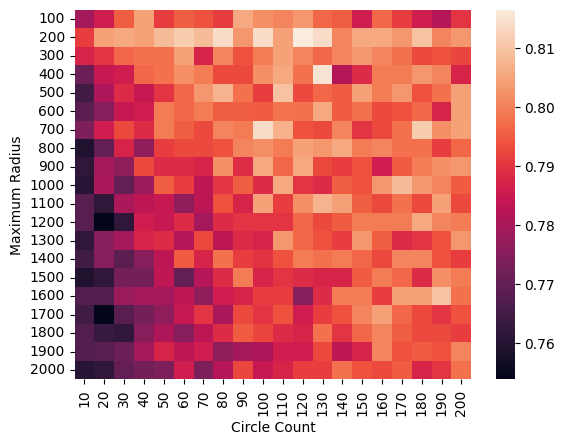

In [42]:
df = pd.DataFrame({
    "Accuracy": [score for score in list(scores.values())],
    "Maximum Radius": [int(key.split("_")[1]) for key in scores if "sholl" in key],
    "Circle Count": [int(key.split("_")[2]) for key in scores if "sholl" in key]
})
df_wide = df.pivot_table(index = "Maximum Radius", columns = "Circle Count", values = "Accuracy")
sns.heatmap(df_wide)
plt.show()

In [209]:
'apical_dendrite_bias_x', 'apical_dendrite_bias_y',
'apical_dendrite_depth_pc_0', 'apical_dendrite_depth_pc_1',
'apical_dendrite_depth_pc_2', 'apical_dendrite_depth_pc_3',
'apical_dendrite_early_branch_path',
'apical_dendrite_emd_with_basal_dendrite',
'apical_dendrite_extent_x', 'apical_dendrite_extent_y',
'apical_dendrite_frac_above_basal_dendrite',
'apical_dendrite_frac_below_basal_dendrite',
'apical_dendrite_frac_intersect_basal_dendrite',
'apical_dendrite_max_branch_order',
'apical_dendrite_max_euclidean_distance',
'apical_dendrite_max_path_distance',
'apical_dendrite_mean_contraction',
'apical_dendrite_mean_diameter',
'apical_dendrite_mean_moments_along_max_distance_projection',
'apical_dendrite_num_branches',
'apical_dendrite_num_outer_bifurcations',
'apical_dendrite_soma_percentile_x',
'apical_dendrite_soma_percentile_y',
'apical_dendrite_std_moments_along_max_distance_projection',
'apical_dendrite_total_length',
'apical_dendrite_total_surface_area', 'axon_exit_distance',
'axon_exit_theta', 'basal_dendrite_bias_x',
'basal_dendrite_bias_y',
'basal_dendrite_calculate_number_of_stems',
'basal_dendrite_extent_x', 'basal_dendrite_extent_y',
'basal_dendrite_frac_above_apical_dendrite',
'basal_dendrite_frac_below_apical_dendrite',
'basal_dendrite_frac_intersect_apical_dendrite',
'basal_dendrite_max_branch_order',
'basal_dendrite_max_euclidean_distance',
'basal_dendrite_max_path_distance',
'basal_dendrite_mean_contraction', 'basal_dendrite_mean_diameter',
'basal_dendrite_num_branches', 'basal_dendrite_soma_percentile_x',
'basal_dendrite_soma_percentile_y',
'basal_dendrite_stem_exit_down', 'basal_dendrite_stem_exit_side',
'basal_dendrite_stem_exit_up', 'basal_dendrite_total_length',
'basal_dendrite_total_surface_area', 'soma_aligned_dist_from_pia',
'soma_surface_area', 'axon_bias_x', 'axon_bias_y',
'axon_depth_pc_0', 'axon_depth_pc_1', 'axon_depth_pc_2',
'axon_depth_pc_3', 'axon_depth_pc_4',
'axon_emd_with_basal_dendrite', 'axon_extent_x', 'axon_extent_y',
'axon_frac_above_basal_dendrite', 'axon_frac_below_basal_dendrite',
'axon_frac_intersect_basal_dendrite', 'axon_max_branch_order',
'axon_max_euclidean_distance', 'axon_max_path_distance',
'axon_mean_contraction', 'axon_num_branches',
'axon_soma_percentile_x', 'axon_soma_percentile_y',
'axon_total_length', 'basal_dendrite_frac_above_axon',
'basal_dendrite_frac_below_axon',
'basal_dendrite_frac_intersect_axon'

'basal_dendrite_frac_intersect_axon'